# AEL hydrogen NPV simulation

Run the Monte Carlo hydrogen model at 100,000 tH2/year. The notebook shows NPV, LPM, and LCOH distributions, NPV sign counts, and mean annual cost components. Greenfield European alkaline electrolysis for 2030, with purchased electricity specified at 200 bar.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from hydrogen.hydrogen_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_hydrogen_results,
)
from npv_summary import summarize_metric_signs
from npv_summary_plots import plot_financial_metric_distribution

pd.options.display.float_format = "{:,.3f}".format

In [2]:
TECHNOLOGY = "ael"
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE

simulation = simulate_hydrogen_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()

,run_id,technology,technology_type,retrofit_bau_mode,annual_output_th2,lifetime_years,capex_eur_per_th2,fixed_opex_eur_per_th2,variable_opex_eur_per_th2,fuel_type,...,annual_electricity_cost_eur,annual_transport_and_storage_cost_eur,annual_emissions_cost_eur,annual_total_cost_eur,annual_net_cash_flow_eur,npv_eur,discounted_lifetime_output_th2,present_value_total_cost_eur,lcoh_eur_per_th2,levelized_profit_margin_eur_per_th2
0,0,ael,absolute,not_applicable,"100,000.000",25,"7,599.737",189.737,31.454,none,...,"677,264,159.692",0.000,0.000,"699,383,291.196","50,616,708.804","-219,651,680.576","1,067,477.619","8,225,733,822.017","7,705.767",-205.767
1,1,ael,absolute,not_applicable,"100,000.000",25,"9,198.475",232.526,28.874,none,...,"752,822,542.499",0.000,0.000,"778,962,601.050","-28,962,601.050","-1,229,016,814.707","1,067,477.619","9,235,098,956.148","8,651.328","-1,151.328"
2,2,ael,absolute,not_applicable,"100,000.000",25,"7,404.058",186.632,32.110,none,...,"628,744,159.284",0.000,0.000,"650,618,333.012","99,381,666.988","320,471,281.597","1,067,477.619","7,685,610,859.844","7,199.786",300.214
3,3,ael,absolute,not_applicable,"100,000.000",25,"9,293.181",276.751,44.864,none,...,"795,596,431.994",0.000,0.000,"827,757,868.988","-77,757,868.988","-1,759,365,912.546","1,067,477.619","9,765,448,053.987","9,148.153","-1,648.153"
4,4,ael,absolute,not_applicable,"100,000.000",25,"6,243.220",212.274,45.422,none,...,"399,034,880.981",0.000,0.000,"424,804,565.126","325,195,434.874","2,847,066,511.851","1,067,477.619","5,159,015,629.590","4,832.903","2,667.097"


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
lcoh_eur_per_th2 = results["lcoh_eur_per_th2"]
levelized_profit_margin_eur_per_th2 = results["levelized_profit_margin_eur_per_th2"]

summary = pd.concat([
    npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename("NPV million EUR"),
    levelized_profit_margin_eur_per_th2.describe(percentiles=[0.05, 0.5, 0.95]).rename("LPM EUR/tH2"),
    lcoh_eur_per_th2.describe(percentiles=[0.05, 0.5, 0.95]).rename("LCOH EUR/tH2"),
], axis=1)
npv_signs = summarize_metric_signs(npv_million_eur)
npv_sign_summary = pd.DataFrame([
    {"NPV category": "Non-negative (NPV >= 0)", "Count": npv_signs["non_negative_count"], "Share": npv_signs["non_negative_share"]},
    {"NPV category": "Negative (NPV < 0)", "Count": npv_signs["negative_count"], "Share": 1 - npv_signs["non_negative_share"]},
])
display(summary, npv_sign_summary)

,NPV million EUR,LPM EUR/tH2,LCOH EUR/tH2
count,"100,000.000","100,000.000","100,000.000"
mean,436.361,408.777,"7,091.223"
std,"1,363.384","1,277.202","1,277.202"
min,"-2,841.522","-2,661.903","4,068.832"
5%,"-1,795.069","-1,681.598","5,008.087"
50%,432.416,405.082,"7,094.918"
95%,"2,660.061","2,491.913","9,181.598"
max,"3,662.695","3,431.168","10,161.903"


,NPV category,Count,Share
0,Non-negative (NPV >= 0),60743,0.607
1,Negative (NPV < 0),39257,0.393


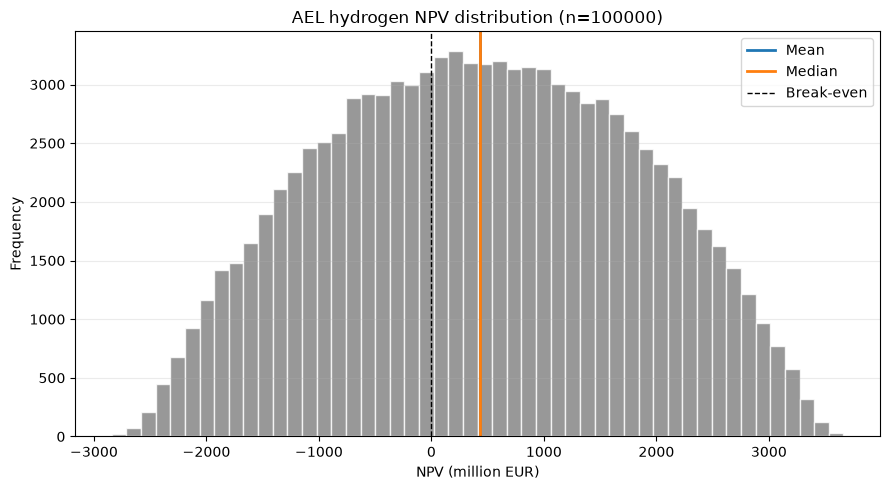

In [4]:
plot_financial_metric_distribution(
    npv_million_eur,
    title=f"AEL hydrogen NPV distribution (n={SAMPLE_SIZE})",
    x_axis_label="NPV (million EUR)",
    color="tab:gray",
    show_break_even=True,
)
plt.show()

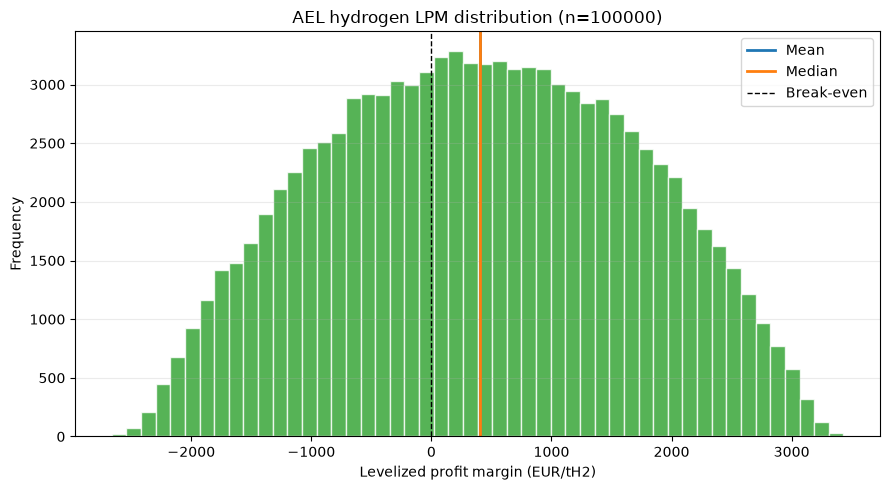

In [5]:
plot_financial_metric_distribution(
    levelized_profit_margin_eur_per_th2,
    title=f"AEL hydrogen LPM distribution (n={SAMPLE_SIZE})",
    x_axis_label="Levelized profit margin (EUR/tH2)",
    color="tab:green",
    show_break_even=True,
)
plt.show()

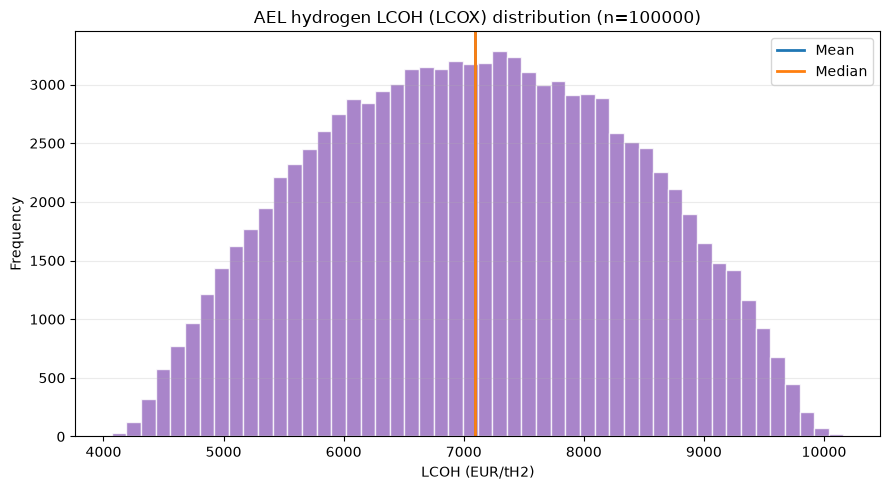

In [6]:
plot_financial_metric_distribution(
    lcoh_eur_per_th2,
    title=f"AEL hydrogen LCOH (LCOX) distribution (n={SAMPLE_SIZE})",
    x_axis_label="LCOH (EUR/tH2)",
    color="tab:purple",
)
plt.show()

In [7]:
annual_columns = [
    "annual_revenue_eur",
    "annual_fixed_opex_eur",
    "annual_variable_opex_eur",
    "annual_natural_gas_cost_eur",
    "annual_biomethane_cost_eur",
    "annual_biomass_cost_eur",
    "annual_fuel_cost_eur",
    "annual_electricity_cost_eur",
    "annual_transport_and_storage_cost_eur",
    "annual_emissions_cost_eur",
    "annual_net_cash_flow_eur",
]
(results[annual_columns] / 1_000_000).mean().rename("Mean annual value, million EUR")

annual_revenue_eur                      750.000
annual_fixed_opex_eur                    24.520
annual_variable_opex_eur                  3.834
annual_natural_gas_cost_eur               0.000
annual_biomethane_cost_eur                0.000
annual_biomass_cost_eur                   0.000
annual_fuel_cost_eur                      0.000
annual_electricity_cost_eur             600.903
annual_transport_and_storage_cost_eur     0.000
annual_emissions_cost_eur                 0.000
annual_net_cash_flow_eur                120.742
Name: Mean annual value, million EUR, dtype: float64